<!-- # MiGut qPCR Data Processing & Upload Pipeline

This notebook provides a complete pipeline for processing qPCR data from MiGut model experiments and uploading it to Azure Cosmos DB for storage and analysis.

## Overview

The pipeline consists of three main stages:

1. **Raw qPCR Data Processing**
   - Processes raw qPCR files from different machines
   - Creates standard curves for each bacterial population
   - Calculates concentrations using these standard curves
   - Exports detailed and pivoted results

2. **Metadata Extraction & Organization**
   - Extracts reactor, vessel, and day information from sample names
   - Allocates donor samples to appropriate reactors
   - Categorizes samples into experimental stages
   - Creates a structured dataset ready for analysis

3. **Azure Cosmos DB Upload**
   - Formats the processed data for database compatibility
   - Uploads the data to Azure Cosmos DB
   - Ensures proper data organization in the cloud

## File Requirements

### qPCR Output Files
- Must be placed in the **`files to extract`** folder
- File naming format: **`<plate information>_<population name>_<additional info>`**
- Example: `Plate1_Bacteroides_03.07.2023`
- **Important**: Population names must be consistent across files

### Sample Name Format
- Format: **`R<reactor number>V<vessel number>D<day number>`**
- Example: `R10V1D14` (Reactor 10, Vessel 1, Day 14)
- **Important**: This format is essential for proper data organization

### Donor Sample Allocation
- Donor samples (Day 0) are allocated to specific reactors
- The allocations are defined in the configuration section
- Each donor sample serves as the baseline for its assigned reactors

## How to Use This Notebook

1. **Prepare Your Data**
   - Place qPCR files in the specified folder
   - Ensure proper file naming
   - Check sample name formatting

2. **Configure Settings**
   - Update machine-specific settings (Rotor-Gene Q or qTOWER iris)
   - Set donor allocations
   - Configure experimental stage definitions
   - Provide Azure Cosmos DB connection details

3. **Run the Pipeline**
   - Execute each cell in sequence (Ctrl+Enter or Run button)
   - Review the outputs at each stage
   - Check for any errors or warnings

4. **Visualization**
   - Use the plotting tools to visualize bacterial populations over time
   - Analyze changes across different experimental stages
   - Compare populations across reactors
   
5. **Uploading to Azure Cosmos DB**
   - Select the target database name
   - Upload pre-processed data to Azure Database for integration with PowerBI

## Troubleshooting

- **Standard Curve Issues**: If standard curves don't look right, adjust the `OUTLIER_LIMIT` parameter
- **Missing Data**: Check that sample names follow the correct format
- **Upload Errors**: Verify Azure connection parameters and network connectivity

---

For detailed information, refer to the "MiGut data guide" document or collapse/expand sections in this notebook by clicking the arrow next to each heading. -->

# 1. Import dependencies
Run the code below to import the required python packages

In [2]:
import pandas as pd      # For data manipulation and analysis
import numpy as np       # For numerical operations
import matplotlib.pyplot as plt  # For creating plots
import scipy.stats      # For statistical functions (like linear regression)
import os               # For interacting with the operating system (like file paths)
from datetime import date  # For working with dates
import uuid             # For generating unique identifiers
from IPython.display import clear_output  # For clearing output in Jupyter notebooks
import re
import uuid
from datetime import datetime
from azure.cosmos import CosmosClient, PartitionKey
print("Libraries read successfully!")

Libraries read successfully!


# 2. Configuration Settings for qPCR Data Processing

This section contains the customizable variables that control how the qPCR data is processed. Adjust these settings to match your specific qPCR machine, file format, and preferences.

## General Settings

- `FILES_DIRECTORY`: The folder containing your qPCR data files
- `OUTPUT_FILE`: Where to save the processed results (set to `None` if you don't want to save)
- `STANDARD_CURVE_FILE`: Where to save information about your standard curves (set to `None` if you don't want to save)
- `OUTLIER_LIMIT`: Controls how aggressively to remove outliers from standard curves (higher number = more permissive)

## Machine-Specific Settings

The code includes pre-configured settings for two common qPCR machines:

1. **Rotor-Gene Q** (HCAI machine)
2. **qTOWER iris** (FSN machine)

To switch between machines, uncomment the settings for your machine and comment out the settings for the other machine.

### Column Mapping

`COLUMN_MAPPING` tells the script how to find important data in your qPCR file:

- `position_col`: The column that contains "Position" or "Well" (used to find the header row)
- `sample_name_col`: Column containing your sample names
- `sample_type_col`: Column identifying whether a sample is a standard or test sample
- `cq_value_col`: Column containing Cq/Ct values
- `concentration_col`: Column containing the known concentrations for standards

### Sample Types

`SAMPLE_TYPES` identifies how your machine labels different types of samples:

- `standard_type`: How standards are labeled in your file (e.g., "QuantificationStandard" or "Standard")
- `test_type`: How test samples are labeled (e.g., "TestSample" or "Unknown")

### Missing Values

`MISSING_CQ_VALUE` tells the script what text indicates a missing or invalid Cq value in your file:

- For Rotor-Gene Q: `"--"`
- For qTOWER iris: `"No Ct"`

## How to Configure

1. Update `FILES_DIRECTORY` to point to your qPCR data files
2. Choose which machine settings to use by commenting/uncommenting the appropriate sections
3. Adjust any other settings as needed for your specific files
4. Run the code to process your qPCR data

In [3]:
#############################################################
# CUSTOMIZATION VARIABLES - CHANGE THESE AS NEEDED
#############################################################

# Directory containing the qPCR files to process
#FILES_DIRECTORY = "files to extract"
FILES_DIRECTORY = "donor01-lacto-mapped-example" #"donor01-bifidis"

# Where to save the output CSV file (set to None if you don't want to save output)
OUTPUT_FILE = "qpcr_results.csv"

# Where to save the standard curve information (set to None if you don't want to save)
STANDARD_CURVE_FILE = "standard_curves.csv"

# Threshold for removing outliers from standard curve
OUTLIER_LIMIT = 5

#############################################################
# Below are different settings for Rotor-Gene Q (HCAI 
# machine) and the qTOWER iris (FSN machine). Comment out 
# the settings that you don't need.
#############################################################

"""
# FILE SETTINGS FOR ROTOR-GENE Q
# Column names in your qPCR file (Rotor-Gene Q)
COLUMN_MAPPING = {
    "position_col": "Position",          # Column that contains "Position" to find header row
    "sample_name_col": "Sample name",    # Column containing sample names
    "sample_type_col": "Sample type",    # Column identifying sample types
    "cq_value_col": "Cq Value",          # Column with Cq values
    "concentration_col": "Given concentration"  # Column with standard concentrations
}

# Sample type identifiers in PCR file (Rotor-Gene Q)
SAMPLE_TYPES = {
    "standard_type": "QuantificationStandard",  # Identifier for standard samples
    "test_type": "TestSample"                   # Identifier for test samples
}

# String used to indicate missing Cq values in your qPCR file (Rotor-Gene Q)
MISSING_CQ_VALUE = "--"
"""

# FILE SETTINGS FOR qTOWER IRIS
# Column names in your qPCR file (qTOWER iris)
COLUMN_MAPPING = {
    "position_col": "Well",          # Column that contains "Position" to find header row
    "sample_name_col": "Sample name",    # Column containing sample names
    "sample_type_col": "Sample type",    # Column identifying sample types
    "cq_value_col": "Ct",          # Column with Cq values
    "concentration_col": "Conc. Std."  # Column with standard concentrations
}

# Sample type identifiers in PCR file (qTOWER iris)
SAMPLE_TYPES = {
    "standard_type": "Standard",  # Identifier for standard samples
    "test_type": "Unknown"                   # Identifier for test samples
}

# String used to indicate missing Cq values in your qPCR file (qTOWER iris)
MISSING_CQ_VALUE = "No Ct"



# 3. Helper and processing functions

This section contains the core functions used to process qPCR data files and extract useful information from them.

## Helper Functions

The `extract_population_name()` function is designed to extract bacterial population names from qPCR data filenames. It works by:

1. Splitting the filename by underscores
2. Assuming the bacterial population name is the second element (index 1) in the split result
3. Returning "Unknown" if the population name can't be determined

For example, with a filename like "Plate1_Bacteroides_20250414", it would extract "Bacteroides" as the population name.

## Data Processing Functions

The code contains two main processing functions:

### 1. `process_qpcr_file()`

This function processes a single qPCR file through these steps:

1. **Data Loading**: Reads the CSV and locates header information
2. **Standard Curve Creation**: 
   - Identifies quantification standards
   - Removes missing Cq values
   - Converts concentrations to log10
   - Performs linear regression to create the standard curve
   - Visualizes the standard curve in before/after plots
   - Removes outliers that deviate significantly from the line
3. **Statistics Collection**: Captures slope, intercept, R² value, and other metadata
4. **Concentration Calculation**: Uses the standard curve to calculate concentrations for all test samples
5. **Result Preparation**: Returns a dataframe with samples and calculated concentrations, plus standard curve information

The function creates useful visualizations with the regression equation displayed directly on the plots, and handles errors gracefully if data columns can't be found.

### 2. `process_all_files()`

This function orchestrates the processing of multiple qPCR files:

1. Iterates through each file in a directory
2. Processes each file using `process_qpcr_file()`
3. Collects all sample data and standard curve information
4. Combines results into comprehensive dataframes
5. Organizes the data by sample and population
6. Calculates statistics like mean concentrations
7. Creates a pivot table for easier analysis
8. Optionally saves results to CSV files

The function returns three dataframes:
- Detailed results with all sample data
- Pivoted results organized by sample and population
- Standard curve information for all processed files

These functions can be customized through parameters like `column_mapping`, `sample_types`, and `missing_cq_value` to adapt to different qPCR data file formats.

In [4]:
#############################################################
# HELPER FUNCTIONS
#############################################################

def extract_population_name(filename):
    """
    Extract bacterial population name from the filename.
    
    The filename format is expected to be: Plate<num>_<population>_date
    For example: "Plate1_Bacteroides_20250414" would return "Bacteroides"
    
    Parameters:
    filename (str): The name of the file
    
    Returns:
    str: The extracted population name or "Unknown" if can't be determined
    """
    # Split the filename by underscore character
    parts = filename.split('_')
    
    # If there are at least 2 parts, the second part should be the population name
    if len(parts) >= 2:
        return parts[1]
    
    # If we couldn't extract the population name, return "Unknown"
    return "Unknown"

#############################################################
# DATA PROCESSING FUNCTIONS
#############################################################

def process_qpcr_file(filepath, column_mapping=COLUMN_MAPPING, 
                     sample_types=SAMPLE_TYPES, 
                     missing_cq_value=MISSING_CQ_VALUE,
                     outlier_limit=OUTLIER_LIMIT):
    """
    Process a single qPCR file and return the calculated concentration data.
    
    This function:
    1. Reads in the qPCR data file
    2. Identifies and processes quantification standards 
    3. Creates a standard curve using linear regression
    4. Uses the standard curve to calculate concentrations for test samples
    
    Parameters:
    filepath (str): Path to the qPCR data file
    column_mapping (dict): Custom mapping for column names in the qPCR file
    sample_types (dict): Custom mapping for sample type identifiers
    missing_cq_value (str): Custom string used to indicate missing Cq values
    outlier_limit (int): Threshold for removing outliers from standard curve
    
    Returns:
    tuple: (result_df, standard_curve_info) - Processed data and standard curve information
    """
    # Get just the filename for display purposes
    filename = os.path.basename(filepath)
    
    # STEP 1: READ AND PREPARE THE DATA
    # ----------------------------------
    
    # Read in the entire CSV with generic column names (since the file doesn't have headers)
    # The letters 'qwertyuiopasdfghjk' are just arbitrary names for columns
    # raw_df = pd.read_csv(filepath, names=list('qwertyuiopasdfghjk'))
    names = list('qwertyuiopasdfghjk')
    raw_df = pd.read_csv(filepath, names=names, header=None, encoding='cp1252', dtype=str)
    
    # Find where the actual data begins by locating the "Position" cell or equivalent
    position_idx = raw_df[raw_df[raw_df.columns[0]] == column_mapping["position_col"]].index
    
    # If we can't find the position column, try to handle gracefully
    if len(position_idx) == 0:
        print(f"Warning: Could not find '{column_mapping['position_col']}' in the file {filename}.")
        print("The first row will be used as the header row.")
        position_idx = [0]  # Use the first row as a fallback
    
    position_idx = position_idx[0]
    
    # Create a subset of the dataframe starting from the "Position" row
    df = raw_df.loc[position_idx:].copy()
    
    # Set the first column as the index
    df.set_index(raw_df.columns[0], inplace=True)
    
    # The first row now contains the real column headers, so use them
    headers = df.iloc[0]
    df = pd.DataFrame(df.values[1:], columns=headers)
    
    # STEP 2: PROCESS QUANTIFICATION STANDARDS (FOR STANDARD CURVE)
    # -------------------------------------------------------------
    
    # Extract rows that are quantification standards
    qs = df[df[column_mapping["sample_type_col"]] == sample_types["standard_type"]]
    
    # Remove any rows with missing Cq values
    qs = qs[qs[column_mapping["cq_value_col"]] != missing_cq_value]
    
    # Keep only the columns we need
    qs = qs[[column_mapping["concentration_col"], column_mapping["cq_value_col"]]]
    
    # Convert columns to numeric values
    qs[column_mapping["concentration_col"]] = pd.to_numeric(qs[column_mapping["concentration_col"]])
    qs[column_mapping["cq_value_col"]] = pd.to_numeric(qs[column_mapping["cq_value_col"]])
    
    # Convert concentrations to log10 scale for linear relationship
    qs[column_mapping["concentration_col"]] = np.log10(qs[column_mapping["concentration_col"]])
    
    # STEP 3: CREATE STANDARD CURVE (LINEAR REGRESSION)
    # ------------------------------------------------
    
    # Calculate the linear regression (standard curve)
    # This gives us: slope, intercept, r_value, p_value, std_err
    regression = scipy.stats.linregress(
        x=qs[column_mapping["concentration_col"]], 
        y=qs[column_mapping["cq_value_col"]]
    )
    
    # Calculate predicted values for each standard using the regression model
    qs["polyfit"] = (qs[column_mapping["concentration_col"]] * regression[0]) + regression[1]
    
    # STEP 4: VISUALIZE THE STANDARD CURVE
    # ------------------------------------
    
    # Clear any previous output (for cleaner notebook display)
    clear_output(wait=True)
    
    # Create a figure with two subplots side by side
    fig, axarr = plt.subplots(1, 2, figsize=(12, 5))
    
    # Set a title for the whole figure showing the filename
    fig.suptitle(f"Standard Curve for {filename}", fontsize=16)
    
    # Plot original data (left subplot)
    axarr[0].scatter(qs[column_mapping["concentration_col"]], qs[column_mapping["cq_value_col"]])
    axarr[0].plot(qs[column_mapping["concentration_col"]], qs["polyfit"], color="r")
    axarr[0].set_title("Original data")
    axarr[0].set_xlabel("Given concentration (log10)")
    axarr[0].set_ylabel("Cq Value")
    
    # Add regression equation to the plot
    equation = f"y = {regression[0]:.4f}x + {regression[1]:.4f}\nR² = {regression[2]**2:.4f}"
    axarr[0].annotate(equation, xy=(0.05, 0.95), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                     va='top', ha='left')
    
    # STEP 5: REMOVE OUTLIERS TO IMPROVE STANDARD CURVE
    # -------------------------------------------------
    
    # Iteratively remove outliers that are far from the regression line
    while True:
        outliers_found = False
        
        # Check each data point
        for index, row in qs.iterrows():
            # Calculate how far this point is from the predicted line
            deviation = abs(row[column_mapping["cq_value_col"]] - row["polyfit"])
            
            # If the deviation exceeds our limit, it's an outlier
            if deviation > outlier_limit:
                outliers_found = True
                
                # Remove the outlier
                qs.drop(labels=index, axis=0, inplace=True)
                
                # Recalculate the regression without this outlier
                regression = scipy.stats.linregress(
                    x=qs[column_mapping["concentration_col"]], 
                    y=qs[column_mapping["cq_value_col"]]
                )
                qs["polyfit"] = (qs[column_mapping["concentration_col"]] * regression[0]) + regression[1]
        
        # If no more outliers were found, we're done
        if not outliers_found:
            break
    
    # Plot filtered data (right subplot)
    axarr[1].scatter(qs[column_mapping["concentration_col"]], qs[column_mapping["cq_value_col"]])
    axarr[1].plot(qs[column_mapping["concentration_col"]], qs["polyfit"], color="r")
    axarr[1].set_title("Filtered data (outliers removed)")
    axarr[1].set_xlabel("Given concentration (log10)")
    axarr[1].set_ylabel("Cq Value")
    
    # Add final regression equation to the plot
    equation = f"y = {regression[0]:.4f}x + {regression[1]:.4f}\nR² = {regression[2]**2:.4f}"
    axarr[1].annotate(equation, xy=(0.05, 0.95), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                     va='top', ha='left')
    
    # Adjust layout and display the plots
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make room for the title
    plt.show()
    
    # Display key statistics about the standard curve along with the filename
    print(f"File: {filename}")
    print(f"Slope: {regression[0]:.4f}")
    print(f"Intercept: {regression[1]:.4f}")
    print(f"R-squared value: {regression[2]**2:.4f}")
    
    # Create a dictionary with standard curve information for this file
    # Extract the population name from the filename
    population = extract_population_name(filename)
    standard_curve_info = {
        'Filename': filename,
        'Population': population,
        'Slope': regression[0],
        'Intercept': regression[1],
        'R_squared': regression[2]**2,
        'Standard_Points': len(qs),
        'Processing_Date': date.today().strftime('%Y-%m-%d')
    }
    
    # STEP 6: CALCULATE CONCENTRATIONS FOR TEST SAMPLES
    # -------------------------------------------------
    
    # Extract rows that are test samples
    sample = df[df[column_mapping["sample_type_col"]] == sample_types["test_type"]]
    
    # Keep only the columns we need
    sample = sample[[column_mapping["sample_name_col"], column_mapping["cq_value_col"]]]
    
    # Create a copy of the Cq values
    sample["Concentration"] = np.nan  # Initialize with NaN values
    
    # Process only valid Cq values (ignoring missing values)
    valid_cq_mask = sample[column_mapping["cq_value_col"]] != missing_cq_value
    
    # Convert valid Cq values to numeric
    valid_samples = sample[valid_cq_mask].copy()
    valid_samples[column_mapping["cq_value_col"]] = pd.to_numeric(valid_samples[column_mapping["cq_value_col"]])
    
    # Calculate concentrations for valid samples
    valid_samples["Concentration"] = (valid_samples[column_mapping["cq_value_col"]] - regression[1]) / regression[0]
    
    # Update the original dataframe with calculated concentrations
    sample.loc[valid_cq_mask, "Concentration"] = valid_samples["Concentration"].values
    
    # Rename columns to standardized names for the output
    result = sample.rename(columns={column_mapping["sample_name_col"]: "Sample name"})
    
    # Return the processed data and standard curve information
    return result[["Sample name", "Concentration"]], standard_curve_info

def process_all_files(directory_path=FILES_DIRECTORY, 
                      column_mapping=COLUMN_MAPPING, 
                      sample_types=SAMPLE_TYPES, 
                      missing_cq_value=MISSING_CQ_VALUE,
                      output_filepath=OUTPUT_FILE,
                      standard_curve_filepath=STANDARD_CURVE_FILE):
    """
    Process all qPCR files in a directory and combine the results.
    
    This function:
    1. Goes through each file in the specified directory
    2. Processes each file to extract concentration data
    3. Combines all data into a single dataframe
    4. Organizes and formats the data for analysis
    5. Optionally saves the results to CSV files
    
    Parameters:
    directory_path (str): Path to directory containing qPCR files
    column_mapping (dict): Custom mapping for column names in the qPCR file
    sample_types (dict): Custom mapping for sample type identifiers
    missing_cq_value (str): Custom string used to indicate missing Cq values
    output_filepath (str): Path where to save the output CSV file (optional)
    standard_curve_filepath (str): Path where to save standard curve info CSV (optional)
    
    Returns:
    tuple: (detailed_results, pivot_results, standard_curve_df) - Processed data and standard curve info
    """
    # List to store data from each file
    all_data = []
    
    # List to store standard curve information for each file
    standard_curve_data = []
    
    # STEP 1: PROCESS EACH FILE IN THE DIRECTORY
    # ------------------------------------------
    
    # Check if directory exists
    if not os.path.isdir(directory_path):
        print(f"Error: Directory '{directory_path}' does not exist.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    
    # Loop through each file in the directory
    for filename in os.listdir(directory_path):
        # Create the full file path
        filepath = os.path.join(directory_path, filename)
        
        # Skip if it's not a file (e.g., if it's a subdirectory)
        if not os.path.isfile(filepath):
            continue
        
        # Extract population name from the filename
        population = extract_population_name(filename)
        print(f"\nProcessing {filename}")
        print(f"Population: {population}")
        
        # Process the file to get concentration data and standard curve info
        try:
            sample_data, std_curve_info = process_qpcr_file(
                filepath, 
                column_mapping=column_mapping,
                sample_types=sample_types, 
                missing_cq_value=missing_cq_value
            )
            
            # Add population column to identify which population this data is for
            sample_data["Population"] = population
            
            # Add this data to our collections
            all_data.append(sample_data)
            standard_curve_data.append(std_curve_info)
            
            # Ask user if they want to continue to the next file
            proceed = input("Proceed with next sample? (y/n): ")
            if proceed.lower() != 'y':
                # If user doesn't want to proceed normally, give options
                retry_limit = input("Set outlier limit to try import again, type 'x' to cancel import, or 'c' to continue to next sample without importing: ")
                
                if retry_limit == 'x':
                    # Cancel the entire process
                    break
                elif retry_limit == 'c':
                    # Skip this file and continue to the next one
                    continue
                elif retry_limit.isnumeric():
                    # Retry processing with a new outlier limit
                    sample_data, std_curve_info = process_qpcr_file(
                        filepath, 
                        column_mapping=column_mapping,
                        sample_types=sample_types, 
                        missing_cq_value=missing_cq_value,
                        outlier_limit=int(retry_limit)
                    )
                    sample_data["Population"] = population
                    # Replace the previously added data for this file
                    all_data[-1] = sample_data
                    standard_curve_data[-1] = std_curve_info
                    
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")
            print("Skipping this file and continuing...")
            continue
    
    # If no data was processed, return empty dataframes
    if not all_data:
        print("No data was processed. Returning empty dataframes.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    
    # Create a dataframe with all standard curve information
    standard_curve_df = pd.DataFrame(standard_curve_data)
    
    # Display the standard curve summary
    print("\nStandard Curve Summary:")
    print(standard_curve_df)
    
    # Save the standard curve information if requested
    if standard_curve_filepath:
        standard_curve_df.to_csv(standard_curve_filepath, index=False)
        print(f"\nStandard curve information saved to: {standard_curve_filepath}")
    
    # STEP 2: COMBINE ALL DATA INTO A SINGLE DATAFRAME
    # ------------------------------------------------
    
    # Combine all the dataframes from different files
    final_df = pd.concat(all_data, ignore_index=True)
    
    # STEP 3: ORGANIZE THE DATA BY SAMPLE AND POPULATION
    # -------------------------------------------------
    
    # Pivot the data to organize by sample name and population
    # This groups duplicate samples together and keeps their concentrations as lists
    final_df = final_df.pivot_table(
        index=["Sample name", "Population"],  # Group by these columns
        values="Concentration",               # The values to aggregate
        aggfunc=lambda x: list(x)            # Keep all values as a list
    ).reset_index()                          # Convert back to a regular dataframe
    
    # STEP 4: SPLIT CONCENTRATION LISTS INTO SEPARATE COLUMNS
    # ------------------------------------------------------
    
    # Find the maximum number of replicates for any sample
    max_replicates = max(len(x) for x in final_df["Concentration"])
    
    # Create a separate column for each replicate
    for i in range(max_replicates):
        final_df[f"Concentration_{i+1}"] = final_df["Concentration"].apply(
            lambda x: x[i] if i < len(x) else np.nan  # Get i-th value or NaN if not present
        )
    
    # Remove the list column since we now have individual columns
    final_df.drop("Concentration", axis=1, inplace=True)
    
    # STEP 5: CALCULATE MEAN CONCENTRATION
    # -----------------------------------
    
    # Identify all the concentration columns
    conc_columns = [col for col in final_df.columns if col.startswith('Concentration_')]
    
    # Calculate the mean across all replicates
    final_df['Mean_Concentration'] = final_df[conc_columns].mean(axis=1)
    
    # STEP 6: CREATE A PIVOTED VIEW FOR EASIER ANALYSIS
    # ------------------------------------------------
    
    # Pivot the data to have samples as rows and populations as columns
    # This makes it easier to compare populations for the same sample
    pivot_df = final_df.pivot(
        index='Sample name',          # Rows will be sample names
        columns='Population',         # Columns will be different populations
        values='Mean_Concentration'   # Values will be mean concentrations
    )
    
    # STEP 7: SAVE RESULTS TO CSV FILES (IF REQUESTED)
    # -----------------------------------------------
    
    if output_filepath:
        # Determine base filename and extension
        base_name, ext = os.path.splitext(output_filepath)
        
        # Save detailed results
        final_df.to_csv(output_filepath, index=False)
        print(f"\nDetailed results saved to: {output_filepath}")
        
        # Save pivoted results
        pivot_filepath = f"{base_name}_pivot{ext}"
        pivot_df.to_csv(pivot_filepath)
        print(f"Pivoted results saved to: {pivot_filepath}")
    
    # Return all three dataframes
    return final_df, pivot_df, standard_curve_df

# 4. Main Program: Running the qPCR Data Analysis

This section executes the main data processing workflow and displays the results. When you run this cell, the program will:

1. Process all qPCR files in your specified directory
2. Generate the standard curves for each population
3. Calculate sample concentrations using these standard curves
4. Organize and format the results
5. Display summary information

## Generated Outputs

The `process_all_files()` function returns three important dataframes:

1. **Detailed Results (`detailed_results`)**
   - Contains complete information about each sample and its replicates
   - Includes sample names, population identifiers, and individual concentration values for each replicate
   - Shows the mean concentration calculated across replicates
   - Useful for detailed analysis and when you need to examine individual replicates
   - If specified in the configuration, this data is saved to the file specified in `OUTPUT_FILE`

2. **Pivoted Results (`pivot_results`)**
   - A reorganized view with samples as rows and bacterial populations as columns
   - Values represent the mean concentration for each sample-population combination
   - Ideal for comparing different bacterial populations across the same samples
   - Makes it easy to see patterns and relationships between different populations
   - If specified in the configuration, this data is saved to a file with "_pivot" added to the name specified in `OUTPUT_FILE`

3. **Standard Curve Information (`standard_curve_df`)**
   - Contains quality control metrics for each standard curve
   - Includes the filename, population name, slope, intercept, and R-squared value
   - Shows how many standard points were used to generate each curve
   - Includes the processing date for record-keeping
   - Critical for assessing the reliability of your qPCR data
   - If specified in the configuration, this data is saved to the file specified in `STANDARD_CURVE_FILE`

## Interpreting the Results

- **R-squared values** close to 1.0 indicate reliable standard curves (typically >0.98 is desirable)
- **Slope values** should ideally be close to -3.32 for 100% PCR efficiency
- The **pivoted results** are particularly useful for comparing relative bacterial abundance across samples
- Check for **missing values** in the detailed results, which indicate samples where the Cq value was missing or invalid

## Next Steps

After reviewing these outputs, you will want to use the sample names to identify additional metadata (reactor, vessel, day of sample) for each sample - this is outlined in the subsequent sections. You can then export the data to analyse it in other software, upload it to PowerBI, or continue analysing it in Python.

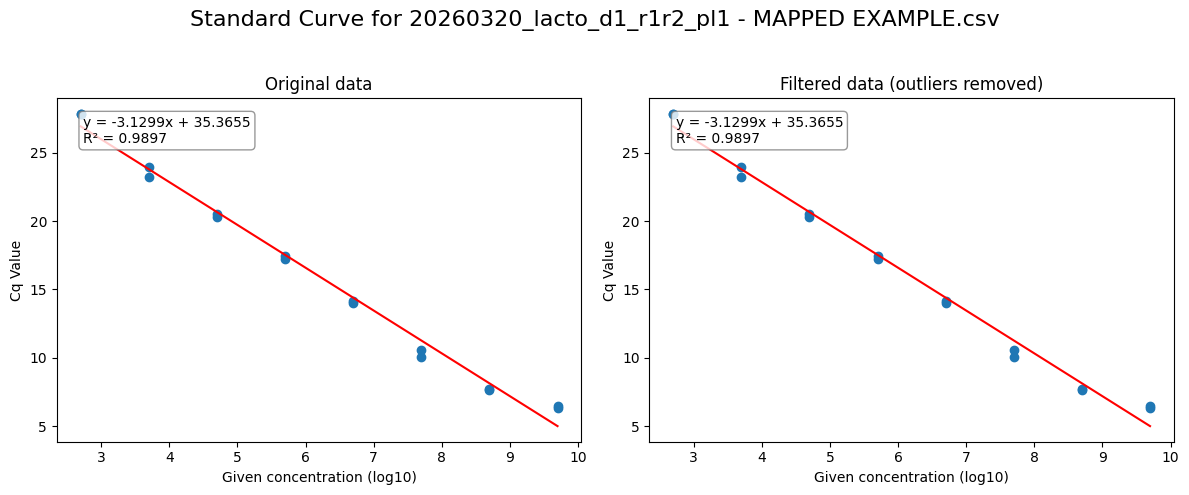

File: 20260320_lacto_d1_r1r2_pl1 - MAPPED EXAMPLE.csv
Slope: -3.1299
Intercept: 35.3655
R-squared value: 0.9897

Standard Curve Summary:
                                          Filename Population    Slope  \
0  20260320_lacto_d1_r1r2_pl1 - MAPPED EXAMPLE.csv      lacto -3.12994   

   Intercept  R_squared  Standard_Points Processing_Date  
0  35.365532   0.989747               16      2026-03-31  

Standard curve information saved to: standard_curves.csv

Detailed results saved to: qpcr_results.csv
Pivoted results saved to: qpcr_results_pivot.csv

Processing complete!

Detailed Results (first 5 rows):
Well Sample name Population  Concentration_1  Concentration_2  \
0        FS_1_D0      lacto         3.123233         3.215886   
1      R1_V1_D10      lacto         0.589638         0.707851   
2      R1_V1_D14      lacto         0.896353         0.813285   
3      R1_V1_D17      lacto         1.011371         1.008176   
4      R1_V1_D19      lacto        -1.052566              NaN  

In [5]:
#############################################################
# MAIN PROGRAM
#############################################################

print("Processing qPCR data...")
detailed_results, pivot_results, standard_curve_df = process_all_files()

# Display completion message
print("\nProcessing complete!")

# Show a preview of the results
print("\nDetailed Results (first 5 rows):")
print(detailed_results.head())

print("\nPivoted Results (first 5 rows):")
print(pivot_results.head())

print("\nStandard Curve Information:")
print(standard_curve_df)

# 5. qPCR Data Processing: Sample Information Extraction and Donor Allocation

This script processes qPCR results data by extracting important metadata from sample names and handling special cases for donor samples. It takes the raw qPCR results and transforms them into a more organized format that's ready for analysis.

## What this script does:

1. **Loads qPCR data** from a CSV file
2. **Extracts metadata from sample names**:
   - Reactor number (R1, R2, etc.)
   - Vessel number (V1, V2, etc.)
   - Day number (D0, D14, etc.)
3. **Handles donor samples** by allocating them to specific reactors
4. **Adds experimental stage information** based on day ranges
5. **Creates a pivot table** for easier analysis
6. **Saves the processed results** to CSV files

## Understanding Your Sample Names

The script extracts information from sample names using pattern recognition. Sample names can be flexible but must include certain patterns:

- **Regular samples** must include:
  - `R` followed by a number (e.g., `R1`, `R12`) to identify the reactor
  - `V` followed by a number (e.g., `V1`, `V3`) to identify the vessel
  - `D` followed by a number (e.g., `D14`, `D28`) to identify the day

- **Examples of valid sample names**:
  - `R1V1D14`: Reactor 1, Vessel 1, Day 14
  - `Plate3_R7V2D21_Sample`: Reactor 7, Vessel 2, Day 21
  - `Test_R12V3D7_Replicate2`: Reactor 12, Vessel 3, Day 7

- **Donor samples** are identified by:
  - The presence of `D0` in the sample name
  - Their exact names must match what's defined in the `DONOR_ALLOCATIONS` dictionary at the top of the script

- **Examples of donor sample names**:
  - `Donor 1 D0 Slurry`
  - `Pooled D0 Slurry`

The information can appear anywhere in the sample name as long as it follows the R#, V#, and D# pattern. The script uses regular expressions to find and extract these patterns regardless of their position in the sample name.

## Donor Sample Allocation

Donor samples represent the "Day 0" starting conditions for your experiment. The script:
1. Identifies all donor samples in your data
2. Removes them from the main dataset (to avoid duplication)
3. Creates new entries that assign each donor to specific reactors based on your configuration
4. Adds these new entries back to the dataset

For example, if "Donor 1 D0 Slurry" is allocated to reactors 1, 5, and 9, that donor's bacterial concentrations will be used as the Day 0 data for those reactors.

## Output Files

The script generates two CSV files:
1. **qpcr_results_processed.csv**: Contains all processed data with added reactor, vessel, and day columns
2. **qpcr_results_processed_pivot.csv**: A restructured pivot table that organizes the data by reactor, vessel, day, and bacterial population

## Customizing the Script

At the top of the script, you can easily modify:
- The input and output file paths
- Donor sample allocations (which reactors each donor is assigned to)
- Experimental stage definitions (which days belong to each experimental stage)

## Experimental Stages

The script automatically assigns each sample to an experimental stage based on the day:
- **Inoculation**: Day 0
- **Steady State**: Days 1-14
- **Spores**: Days 15-21
- **Antibiotic**: Days 22-30
- **Recovery**: Days 31 and beyond

This stage information makes it easier to analyze different phases of your experiment separately.

## When to Use This Script

Run this script after you've processed your raw qPCR data using the main qPCR processing script. This secondary processing step prepares your data for time-series analysis and comparisons between reactors.

In [6]:
# qPCR Data Processing Script
# This script processes qPCR results by:
# 1. Loading the data from a CSV file
# 2. Extracting reactor, vessel, and day information from sample names
# 3. Handling donor samples by allocating them to specific reactors and vessels
# 4. Creating a pivot table for easier analysis
# 5. Saving the processed results to CSV files

#############################################################
# USER CUSTOMIZABLE VARIABLES - CHANGE THESE AS NEEDED
#############################################################

# File path of the qPCR results
FILE_PATH = "qpcr_results.csv"

# Output file paths for processed data
OUTPUT_FILE = "qpcr_results_processed.csv"
OUTPUT_PIVOT_FILE = "qpcr_results_processed_pivot.csv"

# Donor sample allocations
# Each donor sample is mapped to a list of reactor numbers
# Vessels will be 1, 2, and 3 for each reactor
# DONOR_ALLOCATIONS = {
#     "Donor 1 D0 Slurry": [1, 5, 9],   # Donor 1 is allocated to reactors 1, 5, and 9
#     "Donor 2 D0 Slurry": [2, 6, 10],  # Donor 2 is allocated to reactors 2, 6, and 10
#     "Donor 3 D0 Slurry": [3, 7, 11],  # Donor 3 is allocated to reactors 3, 7, and 11
#     "Pooled D0 Slurry": [4, 8, 12]    # Pooled donor is allocated to reactors 4, 8, and 12
# }
DONOR_ALLOCATIONS = {
    "FS_1_D0": [1, 2, 3, 4],   
    "FS_2_D0": [5, 6, 7, 8],
    "FS_3_D0": [9, 10, 11, 12],
}

# Created by Alex
ENTRIES_FOR_VESSELS = [1, 3]

# Experimental stage definitions based on day ranges
# EXPERIMENTAL_STAGES = {
#     "Inoculation": [0],               # Day 0 is inoculation
#     "Steady State": range(1, 15),     # Days 1-14 are steady state
#     "Spores": range(15, 22),          # Days 15-21 are spores
#     "Antibiotic": range(22, 31),      # Days 22-30 are antibiotic
#     "Recovery": range(31, 999)        # Days 31+ are recovery
# }

EXPERIMENTAL_STAGES = {
    "Inoculation": [0],               # Day 0 is inoculation
    "Steady State": range(1, 19),     # Days 1-18 are steady state
    "Dosen": range(19, 35),      # Days 19-34 are dosen
    "Recovery": range(35, 999)        # Days 35+ are recovery
}

#############################################################
# HELPER FUNCTIONS
#############################################################

def extract_sample_info(sample_name):
    """
    Extract reactor number, vessel number, and day from a sample name.
    
    Examples of sample name formats:
    - "R1V1D14" (Reactor 1, Vessel 1, Day 14)
    - "Donor 1 D0 Slurry" (Day 0 donor sample)
    
    Parameters:
    sample_name (str): The name of the sample
    
    Returns:
    tuple: (reactor, vessel, day) - Extracted information
    """
    # Initialize values
    reactor = None
    vessel = None
    day = None
    
    # Extract reactor number (format: R{number})
    reactor_match = re.search(r'R(\d+)', sample_name)
    if reactor_match:
        reactor = int(reactor_match.group(1))
    
    # Extract vessel number (format: V{number})
    vessel_match = re.search(r'V(\d+)', sample_name)
    if vessel_match:
        vessel = int(vessel_match.group(1))
    
    # Extract day (format: D{number})
    day_match = re.search(r'D(\d+)', sample_name)
    if day_match:
        day = int(day_match.group(1))
    
    # Handle special case for donor samples (they are Day 0)
    if "D0" in sample_name:
        day = 0
        
    return reactor, vessel, day

#############################################################
# MAIN PROGRAM
#############################################################

print("Loading qPCR data...")

# Load the qPCR data
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Loaded data with {df.shape[0]} rows and {df.shape[1]} columns")
except Exception as e:
    print(f"Error loading data: {str(e)}")
    # If we can't load the data, we can't continue
    raise

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print("\nSample of data:")
print(df.head())

# Extract reactor, vessel, and day information from sample names
print("\nExtracting reactor, vessel, and day information...")
df[['reactor', 'vessel', 'day']] = df.apply(
    lambda row: pd.Series(extract_sample_info(row['Sample name'])), 
    axis=1
)

# Check for donor samples (samples with "D0" in their name)
donor_samples = df[df['Sample name'].str.contains('D0')]['Sample name'].unique()
print("\nIdentified donor samples:")
for sample in donor_samples:
    print(f"  - {sample}")

# Make a copy of the dataframe for processing
processed_df = df.copy()

# Handle donor allocations
print("\nAllocating donor samples to reactors and vessels...")

# First, remove donor samples from the main dataframe to avoid duplicates
for donor in DONOR_ALLOCATIONS:
    processed_df = processed_df[processed_df['Sample name'] != donor]
    
# Create new rows for each donor with their allocated reactors and vessels
donor_rows = []

for donor, reactors in DONOR_ALLOCATIONS.items():
    # Get the donor data from the original dataframe
    donor_data = df[df['Sample name'] == donor].copy()
    
    if len(donor_data) > 0:
        for reactor_num in reactors:
            # For each reactor assigned to this donor, create entries for vessels 1, 2, and 3
            # for vessel_num in [1,2,3]:
            for vessel_num in ENTRIES_FOR_VESSELS:
                # 1. Make a copy of the donor data
                temp_data = donor_data.copy()
                # 2. Set the reactor number for this copy
                temp_data['reactor'] = reactor_num
                # 3. Set the vessel number to the current vessel in the loop
                temp_data['vessel'] = vessel_num
                # 4. Add to our collection of new rows
                donor_rows.append(temp_data)

# Combine all the donor rows into a single dataframe
if donor_rows:
    donors_df = pd.concat(donor_rows)
    # Add the donor rows back to the processed dataframe
    processed_df = pd.concat([processed_df, donors_df])

# Reset index numbers
processed_df = processed_df.reset_index(drop=True)

# Display a sample of the processed data
print("\nProcessed data sample:")
print(processed_df.head())

# Verify the reactor and vessel assignments for donor samples
print("\nDonor sample reactor and vessel assignments:")
for donor in DONOR_ALLOCATIONS:
    # Group by donor sample and show its reactor-vessel combinations
    donor_assignments = processed_df[processed_df['Sample name'] == donor].groupby(['reactor', 'vessel']).size().reset_index()
    print(f"{donor}:")
    for _, row in donor_assignments.iterrows():
        print(f"  - Reactor {row['reactor']}, Vessel {row['vessel']}")

# Add experimental stage information based on day
print("\nAdding experimental stage information...")

# Create a function to determine stage from day
def get_experimental_stage(day):
    """
    Determine the experimental stage based on the day number.
    
    Parameters:
    day (int): The experimental day
    
    Returns:
    str: The name of the experimental stage
    """
    # Check each stage's day range
    for stage_name, days in EXPERIMENTAL_STAGES.items():
        if day in days:
            return stage_name
    
    # If no match found, return 'Unknown'
    return 'Unknown'

# Apply the function to add the stage column
processed_df['stage'] = processed_df['day'].apply(get_experimental_stage)

# Show the distribution of stages
stage_counts = processed_df['stage'].value_counts()
print("\nDistribution of experimental stages:")
for stage, count in stage_counts.items():
    print(f"  - {stage}: {count} samples")

# Create a pivot table for easier analysis
# This restructures the data to have one row per reactor-vessel-day combination
print("\nCreating pivot table...")

# Create the pivot table WITHOUT Sample name in the index to avoid losing donor samples
pivot_df = processed_df.pivot_table(
    index=['reactor', 'vessel', 'day', 'stage'],     # Group by these columns (not including Sample name)
    columns='Population',                           # Make each bacterial population a column
    values='Mean_Concentration',                    # Use the mean concentration as values
    aggfunc='mean'                                  # If duplicates exist, take the mean
).reset_index()                                     # Convert back to a regular dataframe

# Add Sample name as a regular column (not part of the index)
# We'll merge it back based on reactor, vessel, day
sample_names = processed_df.groupby(['reactor', 'vessel', 'day']).agg({
    'Sample name': lambda x: ', '.join(sorted(set(x)))  # Join multiple sample names if needed
}).reset_index()

# Merge the sample names back to the pivot table
pivot_df = pd.merge(
    pivot_df, 
    sample_names, 
    on=['reactor', 'vessel', 'day'], 
    how='left'
)

# Display a sample of the pivot table
print("\nPivot table sample:")
print(pivot_df.head())

# Save the processed dataframes to CSV files
print("\nSaving processed data to CSV files...")
processed_df.to_csv(OUTPUT_FILE, index=False)
pivot_df.to_csv(OUTPUT_PIVOT_FILE)

print("\nFiles saved:")
print(f"  - {OUTPUT_FILE}: Contains all data with reactor, vessel, and day columns")
print(f"  - {OUTPUT_PIVOT_FILE}: Pivot table by reactor, vessel, day, and population")

print("\nProcessing complete!")

Loading qPCR data...
Loaded data with 39 rows and 5 columns
Dataset shape: (39, 5)

Sample of data:
  Sample name Population  Concentration_1  Concentration_2  Mean_Concentration
0     FS_1_D0      lacto         3.123233         3.215886            3.169559
1   R1_V1_D10      lacto         0.589638         0.707851            0.648745
2   R1_V1_D14      lacto         0.896353         0.813285            0.854819
3   R1_V1_D17      lacto         1.011371         1.008176            1.009774
4   R1_V1_D19      lacto        -1.052566              NaN           -1.052566

Extracting reactor, vessel, and day information...

Identified donor samples:
  - FS_1_D0

Allocating donor samples to reactors and vessels...

Processed data sample:
  Sample name Population  Concentration_1  Concentration_2  \
0   R1_V1_D10      lacto         0.589638         0.707851   
1   R1_V1_D14      lacto         0.896353         0.813285   
2   R1_V1_D17      lacto         1.011371         1.008176   
3   R1_V1_

In [7]:
# qPCR Data Processing Script - dates instead of day

# qPCR Data Processing Script
# This script processes qPCR results by:
# 1. Loading the data from a CSV file
# 2. Extracting reactor, vessel, and day information from sample names
# 3. Handling donor samples by allocating them to specific reactors and vessels
# 4. Creating a pivot table for easier analysis
# 5. Saving the processed results to CSV files

import pandas as pd
import re
from datetime import datetime, timedelta

#############################################################
# USER CUSTOMIZABLE VARIABLES - CHANGE THESE AS NEEDED
#############################################################

# File path of the qPCR results
FILE_PATH = "qpcr_results.csv"

# Output file paths for processed data
OUTPUT_FILE = "qpcr_results_processed.csv"
OUTPUT_PIVOT_FILE = "qpcr_results_processed_pivot.csv"

# Experiment start date (Day 0)
# START_DATE = datetime(2026, 1, 7)  # 7th Jan 2026
START_DATE = datetime(2025, 11, 18)


# Donor sample allocations
# Each donor sample is mapped to a list of reactor numbers
# Vessels will be 1, 2, and 3 for each reactor
# TODO: Confirm with Will if DONOR_ALLOCATIONS needs to be re-assigned here (already done 1 time previously)
# DONOR_ALLOCATIONS = {
#     "FS A (18-40)": [1,5,9],
#     "FS B (18-40)": [2,6,10],
#     "FS C (&gt;60)": [3,7,11],
#     "FS D (&gt;60)": [4,8,12]
# }

# Experimental stage definitions based on day ranges
# TODO: Confirm with Will if EXPERIMENTAL_STAGES needs to be re-assigned here (already done 1 time previously)
# EXPERIMENTAL_STAGES = {
#     "Inoculation": [0],
#     "Steady State": range(1, 13),
#     "Ceftriaxone": range(14, 20),
#     "Recovery": range(21, 999)
# }

#############################################################
# HELPER FUNCTIONS
#############################################################

# def extract_sample_info(sample_name): # TODO: Function name repetition, needs reassignment!
def extract_sample_info_with_dates(sample_name):
    """
    Extract reactor number, vessel number, and day from a sample name.
    
    Examples of sample name formats:
    - "R1.V1_15.10" (Reactor 1, Vessel 1, 15th October 2025)
    - "R1.V2_08.10" (Reactor 1, Vessel 2, 8th October 2025 - Day 0)
    - "Donor 1 D0 Slurry" (Day 0 donor sample)
    
    Parameters:
    sample_name (str): The name of the sample
    
    Returns:
    tuple: (reactor, vessel, day) - Extracted information
    """
    # Initialize values
    reactor = None
    vessel = None
    day = None
    
    # Extract reactor number (format: R{number})
    reactor_match = re.search(r'R(\d+)', sample_name)
    if reactor_match:
        reactor = int(reactor_match.group(1))
    
    # Extract vessel number (format: V{number})
    vessel_match = re.search(r'V(\d+)', sample_name)
    if vessel_match:
        vessel = int(vessel_match.group(1))
    
    # Extract date (format: _{dd}.{mm} or just {dd}.{mm})
    # date_match = re.search(r'_?(\d{1,2})\.(\d{1,2})', sample_name)
    date_match = re.search(r'D(\d+)', sample_name)
    if date_match and int(date_match.group(1)) == 0:
        day = 0  # Day 0 is the start date
    elif date_match and int(date_match.group(1)) != 0:
        # Calculate the sample date based on the extracted day number
        sample_date = START_DATE + timedelta(days=int(date_match.group(1)))
        # Calculate experimental day (difference from start date)
        day = (sample_date - START_DATE).days
    else:
        raise ValueError(f"Could not extract date from sample name: {sample_name}")
    # # Handle special case for donor/slurry samples (they are Day 0)
    # if "D0" in sample_name or "Slurry" in sample_name:
    #     day = 0
        
    return reactor, vessel, day

#############################################################
# MAIN PROGRAM
#############################################################

print("Loading qPCR data...")

# Load the qPCR data
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Loaded data with {df.shape[0]} rows and {df.shape[1]} columns")
except Exception as e:
    print(f"Error loading data: {str(e)}")
    # If we can't load the data, we can't continue
    raise

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print("\nSample of data:")
print(df.head())

# Extract reactor, vessel, and day information from sample names
print("\nExtracting reactor, vessel, and day information...")
df[['reactor', 'vessel', 'day']] = df.apply(
    lambda row: pd.Series(extract_sample_info_with_dates(row['Sample name'])),
    axis=1
)

# Check for donor samples (samples with "D0" or "Slurry" in their name)
donor_samples = df[df['Sample name'].str.contains('D0|Slurry', case=False, na=False)]['Sample name'].unique()
print("\nIdentified donor samples:")
for sample in donor_samples:
    print(f"  - {sample}")

# Make a copy of the dataframe for processing
processed_df = df.copy()

# Handle donor allocations
print("\nAllocating donor samples to reactors and vessels...")

# First, remove donor samples from the main dataframe to avoid duplicates
for donor in DONOR_ALLOCATIONS:
    processed_df = processed_df[processed_df['Sample name'] != donor]

# Create new rows for each donor with their allocated reactors and vessels
donor_rows = []

for donor, reactors in DONOR_ALLOCATIONS.items():
    # Get the donor data from the original dataframe
    donor_data = df[df['Sample name'] == donor].copy()
    
    if len(donor_data) > 0:
        for reactor_num in reactors:
            # For each reactor assigned to this donor, create entries for vessels 1, 2, and 3
            # for vessel_num in [1, 2, 3]:
            for vessel_num in ENTRIES_FOR_VESSELS:
                # 1. Make a copy of the donor data
                temp_data = donor_data.copy()
                # 2. Set the reactor number for this copy
                temp_data['reactor'] = reactor_num
                # 3. Set the vessel number to the current vessel in the loop
                temp_data['vessel'] = vessel_num
                # 4. Add to our collection of new rows
                donor_rows.append(temp_data)

# Combine all the donor rows into a single dataframe
if donor_rows:
    donors_df = pd.concat(donor_rows)
    # Add the donor rows back to the processed dataframe
    processed_df = pd.concat([processed_df, donors_df])

# Reset index numbers
processed_df = processed_df.reset_index(drop=True)

# Display a sample of the processed data
print("\nProcessed data sample:")
print(processed_df.head())

# Verify the reactor and vessel assignments for donor samples
print("\nDonor sample reactor and vessel assignments:")
for donor in DONOR_ALLOCATIONS:
    # Group by donor sample and show its reactor-vessel combinations
    donor_assignments = processed_df[processed_df['Sample name'] == donor].groupby(['reactor', 'vessel']).size().reset_index()
    print(f"{donor}:")
    for _, row in donor_assignments.iterrows():
        print(f"  - Reactor {row['reactor']}, Vessel {row['vessel']}")

# Add experimental stage information based on day
print("\nAdding experimental stage information...")

# Create a function to determine stage from day
def get_experimental_stage(day):
    """
    Determine the experimental stage based on the day number.
    
    Parameters:
    day (int): The experimental day
    
    Returns:
    str: The name of the experimental stage
    """
    # Check each stage's day range
    for stage_name, days in EXPERIMENTAL_STAGES.items():
        if day in days:
            return stage_name
    
    # If no match found, return 'Unknown'
    return 'Unknown'

# Apply the function to add the stage column
processed_df['stage'] = processed_df['day'].apply(get_experimental_stage)

# Show the distribution of stages
stage_counts = processed_df['stage'].value_counts()
print("\nDistribution of experimental stages:")
for stage, count in stage_counts.items():
    print(f"  - {stage}: {count} samples")

# Create a pivot table for easier analysis
# This restructures the data to have one row per reactor-vessel-day combination
print("\nCreating pivot table...")

# Create the pivot table WITHOUT Sample name in the index to avoid losing donor samples
pivot_df = processed_df.pivot_table(
    index=['reactor', 'vessel', 'day', 'stage'],     # Group by these columns (not including Sample name)
    columns='Population',                           # Make each bacterial population a column
    values='Mean_Concentration',                    # Use the mean concentration as values
    aggfunc='mean'                                  # If duplicates exist, take the mean
).reset_index()                                     # Convert back to a regular dataframe

# Add Sample name as a regular column (not part of the index)
# We'll merge it back based on reactor, vessel, day
sample_names = processed_df.groupby(['reactor', 'vessel', 'day']).agg({
    'Sample name': lambda x: ', '.join(sorted(set(x)))  # Join multiple sample names if needed
}).reset_index()

# Merge the sample names back to the pivot table
pivot_df = pd.merge(
    pivot_df, 
    sample_names, 
    on=['reactor', 'vessel', 'day'], 
    how='left'
)

# Display a sample of the pivot table
print("\nPivot table sample:")
print(pivot_df.head())

# Save the processed dataframes to CSV files
print("\nSaving processed data to CSV files...")
processed_df.to_csv(OUTPUT_FILE, index=False)
pivot_df.to_csv(OUTPUT_PIVOT_FILE, index=False)

print("\nFiles saved:")
print(f"  - {OUTPUT_FILE}: Contains all data with reactor, vessel, and day columns")
print(f"  - {OUTPUT_PIVOT_FILE}: Pivot table by reactor, vessel, day, and population")

print("\nProcessing complete!")



Loading qPCR data...
Loaded data with 39 rows and 5 columns
Dataset shape: (39, 5)

Sample of data:
  Sample name Population  Concentration_1  Concentration_2  Mean_Concentration
0     FS_1_D0      lacto         3.123233         3.215886            3.169559
1   R1_V1_D10      lacto         0.589638         0.707851            0.648745
2   R1_V1_D14      lacto         0.896353         0.813285            0.854819
3   R1_V1_D17      lacto         1.011371         1.008176            1.009774
4   R1_V1_D19      lacto        -1.052566              NaN           -1.052566

Extracting reactor, vessel, and day information...

Identified donor samples:
  - FS_1_D0

Allocating donor samples to reactors and vessels...

Processed data sample:
  Sample name Population  Concentration_1  Concentration_2  \
0   R1_V1_D10      lacto         0.589638         0.707851   
1   R1_V1_D14      lacto         0.896353         0.813285   
2   R1_V1_D17      lacto         1.011371         1.008176   
3   R1_V1_

# 6. Plotting qPCR Data: Bacterial Population Time Series

This script creates a time series plot showing how the concentration of a selected bacterial population changes over the course of your experiment. Each line on the plot represents a different reactor, allowing you to compare how the bacterial population behaves in different conditions.

## What this plot shows:

- **X-axis**: Experimental day (where Day 0 is the donor sample/starting point)
- **Y-axis**: Bacterial concentration (in log10 scale), ranging from 2.7 to 12.7 (the limits of detection)
- **Lines**: Each colored line represents a different reactor
- **Data points**: Individual measurements at each time point

## Customizing the Plot

At the top of the script, you can easily modify these settings:

1. **File Path**: Where to find your processed qPCR data
2. **Population Selection**: Which bacterial population to analyze
3. **Vessel Selection**: Which vessel to focus on (or set to `None` to see all vessels)
4. **Plot Appearance**: Adjust size, line thickness, font sizes, etc.
5. **Reactor Colors**: Change the color scheme for different reactors

## How to Use This Script

1. Make sure you've already run the qPCR data processing script to create the processed CSV file
2. Set `SELECTED_POPULATION` to the bacterial population you want to analyze
3. Set `SELECTED_VESSEL` to the specific vessel you want to focus on (or `None` to see all vessels)
4. Run the script to generate the plot

## Interpreting the Results

- **Upward trends** indicate bacterial population growth over time
- **Downward trends** indicate population decline
- **Comparing reactors** can reveal differences in bacterial growth under different conditions
- **Day 0 values** come from the donor samples you allocated in the previous script

## Troubleshooting

If your plot doesn't appear as expected:

- Check that the population name exactly matches one in your data
- Verify that the vessel number exists in your dataset
- Ensure your data has measurements for multiple days to show a time series

Loading processed qPCR data from qpcr_results_processed_pivot.csv...
Loaded data with 46 rows and 6 columns
Filtered data to show only Vessel 3
Found 4 reactors in the data: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


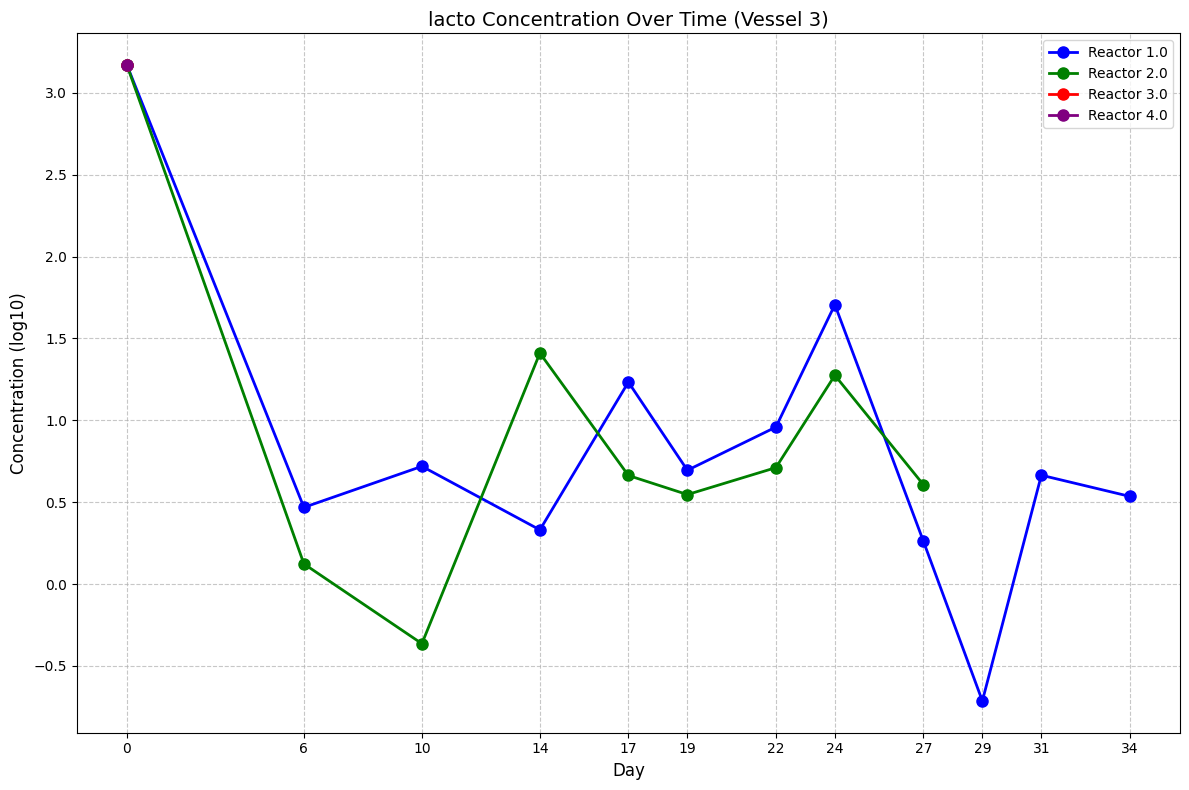

Plot created successfully!


In [8]:
# Plot qPCR Data: Concentration over Time
# This script creates a line plot showing how bacterial concentration changes over time
# Each line represents a different reactor

#############################################################
# USER CUSTOMIZABLE VARIABLES - CHANGE THESE AS NEEDED
#############################################################

# File path of the processed qPCR results (pivot table format is best)
FILE_PATH = "qpcr_results_processed_pivot.csv"

# Select which bacterial population to plot
# SELECTED_POPULATION = "Enterococcus"  # Change to the population you want to analyze
# SELECTED_POPULATION = "bifids"
SELECTED_POPULATION = "lacto"

# Select which vessel to plot (set to None to view all vessels)
# SELECTED_VESSEL = 3  # Change to the vessel number you want to view, or None for all
# SELECTED_VESSEL = None
# SELECTED_VESSEL = 1
SELECTED_VESSEL = 3

# Plot appearance settings
FIGURE_WIDTH = 12        # Width of the plot (inches)
FIGURE_HEIGHT = 8        # Height of the plot (inches)
LINE_WIDTH = 2           # Thickness of the lines
MARKER_SIZE = 8          # Size of the data points
TITLE_FONT_SIZE = 14     # Font size for the title
AXIS_FONT_SIZE = 12      # Font size for axis labels
LEGEND_FONT_SIZE = 10    # Font size for the legend

# Colors for each reactor (you can add more or change these)
REACTOR_COLORS = {
    1: 'blue', 2: 'green', 3: 'red', 4: 'purple',
    5: 'orange', 6: 'brown', 7: 'pink', 8: 'gray',
    9: 'cyan', 10: 'magenta', 11: 'lime', 12: 'teal'
}

#############################################################
# MAIN PROGRAM
#############################################################

# Load the processed qPCR data
print(f"Loading processed qPCR data from {FILE_PATH}...")
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Loaded data with {df.shape[0]} rows and {df.shape[1]} columns")
except Exception as e:
    print(f"Error loading data: {str(e)}")
    raise  # Stop if we can't load the data

# Check if the selected population exists in the data
if SELECTED_POPULATION not in df.columns:
    print(f"Error: Population '{SELECTED_POPULATION}' not found in the data.")
    print("Available populations:", [col for col in df.columns if col not in ['reactor', 'vessel', 'day', 'Sample name']])
    raise ValueError(f"Population '{SELECTED_POPULATION}' not found")

# Filter data by selected vessel if specified
if SELECTED_VESSEL is not None:
    if 'vessel' in df.columns:  # Make sure vessel column exists
        df = df[df['vessel'] == SELECTED_VESSEL]
        print(f"Filtered data to show only Vessel {SELECTED_VESSEL}")
    else:
        print("Warning: 'vessel' column not found in data, showing all vessels")

# Check if we have any data after filtering
if len(df) == 0:
    print("No data available after filtering. Please check your vessel selection.")
    raise ValueError("No data available after filtering")

# Create the plot
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))

# Get unique reactors for the legend
unique_reactors = sorted(df['reactor'].unique())
print(f"Found {len(unique_reactors)} reactors in the data: {unique_reactors}")

# Plot each reactor as a separate line
for reactor in unique_reactors:
    # Filter data for this reactor
    reactor_data = df[df['reactor'] == reactor].copy()
    
    # Sort by day to ensure the line plots correctly
    reactor_data = reactor_data.sort_values('day')
    
    # Get the data for plotting
    days = reactor_data['day']
    concentrations = reactor_data[SELECTED_POPULATION]
    
    # Set the color for this reactor (use a default if not in our dictionary)
    color = REACTOR_COLORS.get(reactor, 'black')
    
    # Plot this reactor's data as a line with markers
    plt.plot(days, concentrations, marker='o', linestyle='-', 
             linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
             label=f'Reactor {reactor}', color=color)

# Add labels and title
vessel_text = f"Vessel {SELECTED_VESSEL}" if SELECTED_VESSEL is not None else "All Vessels"
plt.title(f'{SELECTED_POPULATION} Concentration Over Time ({vessel_text})', 
          fontsize=TITLE_FONT_SIZE)
plt.xlabel('Day', fontsize=AXIS_FONT_SIZE)
plt.ylabel('Concentration (log10)', fontsize=AXIS_FONT_SIZE)

# Set y-axis limits to the specified limits of detection
# plt.ylim(2.7, 12.7)

# Improve x-axis ticks to show only days that exist in the data
all_days = sorted(df['day'].unique())
plt.xticks(all_days)

# Add grid lines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add a legend to identify each reactor
plt.legend(fontsize=LEGEND_FONT_SIZE)

# Make sure everything fits well
plt.tight_layout()

# Show the plot
plt.show()

print("Plot created successfully!")

# 7. Uploading qPCR Data to Azure Cosmos DB

This script takes your processed qPCR data and uploads it to Azure Cosmos DB. It handles the necessary formatting and data transformations to ensure your data is properly stored in the database.

## What this script does:

1. **Loads your processed qPCR data** from the CSV file
2. **Prepares the data** for Azure Cosmos DB by:
   - Adding date information if not present
   - Renaming columns to match the database schema
   - Converting numeric values to the correct formats
   - Ensuring vessel numbers are properly formatted
3. **Converts the data** into individual items for upload
4. **Uploads the data** to your Azure Cosmos DB account

## Before running this script:

1. Make sure you have the Azure Cosmos DB Python SDK installed. If not, install it with:
   ```
   pip install azure-cosmos
   ```

2. Ensure you have your processed qPCR data available (the output from the previous processing script)

3. Check that you have your Azure Cosmos DB connection information:
   - Endpoint URL
   - Primary Key
   - Database name
   - Container name

## Configuration Settings

At the top of the script, you can customize:

- **INPUT_FILE**: Path to your processed qPCR data file
- **COSMOS_ENDPOINT**: Your Azure Cosmos DB endpoint URL
- **COSMOS_KEY**: Your Azure Cosmos DB access key
- **DATABASE_NAME**: Name of your database
- **CONTAINER_NAME**: Name of your container
- **PERFORM_UPLOAD**: Set to True to upload data, False to just prepare it without uploading
- **RECORD_DATE**: Date to use for all records (defaults to today if None)

## Database Structure

The script formats your data to match this structure in Azure Cosmos DB:

- **id**: A unique identifier for each record
- **date**: Date of the record
- **population**: Name of the bacterial population
- **reactor**: Reactor number
- **vessel**: Vessel identifier
- **stage**: Experimental stage (inoculation, steady state, etc.)
- **day**: Day of the experiment
- **val**: The bacterial concentration value

## After running the script:

Your qPCR data will be accessible in Azure Cosmos DB, where you can:
- Query it using the Azure portal
- Connect to it from Power BI for visualization
- Access it through other applications using the Cosmos DB API

In [ ]:
# Azure Cosmos DB Upload Script for qPCR Data
# This script takes processed qPCR data and uploads it to Azure Cosmos DB
# It formats the data according to the required structure for the database

#############################################################
# USER CUSTOMIZABLE VARIABLES - CHANGE THESE AS NEEDED
#############################################################

# File path to the processed qPCR results
INPUT_FILE = "qpcr_results_processed.csv"

# Azure Cosmos DB connection parameters
COSMOS_ENDPOINT = "https://gutmodel.documents.azure.com:443/"
COSMOS_KEY = "ZlSUih8XALgFci8Y4JwdCEc6h1IMPou27RYdJXC8aJnzxKwjYrH2MDUd50jYl9mh9QJOmm6vL0314QwD1s5Exg=="
DATABASE_NAME = "Nia PhD"
CONTAINER_NAME = "Nia Cdiff models January 2025"

# Set to True to actually upload the data, False to just prepare it without uploading
PERFORM_UPLOAD = True

# Date to use for the records (defaults to today if left as None)
RECORD_DATE = None  # Example: "2025-04-15" or None for today's date

#############################################################
# HELPER FUNCTIONS
#############################################################

def prepare_data_for_cosmos(df):
    """
    Convert the processed qPCR dataframe to the format needed for Cosmos DB
    
    Parameters:
    df (DataFrame): The processed qPCR dataframe
    
    Returns:
    DataFrame: The prepared dataframe with the correct structure for Cosmos DB
    """
    print("Preparing data for Cosmos DB...")
    
    # Create a copy to avoid modifying the original
    cosmos_df = df.copy()
    
    # Make sure we have the required columns
    required_columns = ['reactor', 'vessel', 'day', 'stage', 'Population', 'Mean_Concentration']
    missing_columns = [col for col in required_columns if col not in cosmos_df.columns]
    
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    
    # Add date information if not already present
    if 'date' not in cosmos_df.columns:
        # Use the specified date or today's date
        date_to_use = RECORD_DATE if RECORD_DATE else datetime.now().strftime('%Y-%m-%d')
        cosmos_df['date'] = date_to_use
        print(f"Added date column with value: {date_to_use}")
    
    # Rename columns to match the Cosmos DB schema
    cosmos_df = cosmos_df.rename(columns={
        'Mean_Concentration': 'Mean',
        'Population': 'population'
    })
    
    # Convert numeric columns to strings (as required by Cosmos DB)
    cosmos_df['reactor'] = cosmos_df['reactor'].astype(str)
    cosmos_df['day'] = cosmos_df['day'].astype(str)
    
    # Make sure Mean is numeric (in case there are any string values)
    cosmos_df['Mean'] = pd.to_numeric(cosmos_df['Mean'], errors='coerce')
    
    # Convert vessel to string if it's not already
    if not pd.api.types.is_string_dtype(cosmos_df['vessel']):
        cosmos_df['vessel'] = cosmos_df['vessel'].astype(str)
        # Add 'V' prefix if it's missing
        if not cosmos_df['vessel'].str.startswith('V').any():
            cosmos_df['vessel'] = 'V' + cosmos_df['vessel']
    
    # Set up a MultiIndex to match the expected input for itemize_data
    # This groups the data by date, population, reactor, and vessel
    cosmos_df = cosmos_df.set_index(['date', 'population', 'reactor', 'vessel'])
    
    print(f"Data preparation complete. {len(cosmos_df)} rows ready for upload.")
    
    return cosmos_df

def convert_row_to_cosmos_item(index, row):
    """
    Convert a row from the dataframe to a data item for Cosmos DB
    
    Parameters:
    index: The MultiIndex from the dataframe (contains date, population, reactor, vessel)
    row: The data for this row
    
    Returns:
    dict: A dictionary formatted for Cosmos DB
    """
    # Create a unique ID for each record
    unique_id = str(uuid.uuid4())
    
    # Create the data item in the format required by Cosmos DB
    data_item = {
        'id': unique_id,           # Unique identifier
        'date': index[0],          # Date of the record
        'population': index[1],    # Bacterial population name
        'reactor': index[2],       # Reactor number
        'vessel': index[3],        # Vessel identifier
        'stage': row["stage"],     # Experimental stage
        'day': row["day"],         # Day of the experiment
        'val': str(row["Mean"])    # The concentration value (as string)
    }
    
    return data_item

def convert_dataframe_to_cosmos_items(df):
    """
    Convert the entire dataframe to a list of data items for Cosmos DB
    
    Parameters:
    df (DataFrame): The prepared dataframe with MultiIndex
    
    Returns:
    list: A list of dictionaries ready for upload to Cosmos DB
    """
    cosmos_items = []
    
    # Process each row in the dataframe
    for index, row in df.iterrows():
        # Convert the row to a Cosmos DB item
        data_item = convert_row_to_cosmos_item(index, row)
        # Add it to our collection
        cosmos_items.append(data_item)
    
    return cosmos_items

def upload_to_cosmos_db(items, endpoint, key, database_name, container_name):
    """
    Upload the data items to Azure Cosmos DB
    
    Parameters:
    items (list): List of data items to upload
    endpoint (str): Cosmos DB endpoint URL
    key (str): Cosmos DB access key
    database_name (str): Name of the database
    container_name (str): Name of the container
    """
    print(f"\nConnecting to Azure Cosmos DB at {endpoint}...")
    
    try:
        # Initialize the Cosmos client
        client = CosmosClient(endpoint, key)
        
        # Get or create the database
        database = client.create_database_if_not_exists(id=database_name)
        print(f"Connected to database: '{database_name}'")
        
        # Get or create the container
        container = database.create_container_if_not_exists(
            id=container_name, 
            partition_key=PartitionKey(path="/id"),  # We're partitioning by the unique ID
            offer_throughput=400  # Minimum throughput
        )
        print(f"Connected to container: '{container_name}'")
        
        # Upload each item to Cosmos DB
        print(f"Starting upload of {len(items)} items...")
        
        for i, item in enumerate(items):
            # Create the item in the container
            container.create_item(body=item)
            
            # Print progress periodically
            if (i + 1) % 50 == 0 or (i + 1) == len(items):
                print(f"Progress: {i + 1}/{len(items)} items uploaded ({(i + 1)/len(items)*100:.1f}%)")
        
        print(f"\nUpload complete! Successfully uploaded {len(items)} items to Azure Cosmos DB.")
    
    except Exception as e:
        print(f"Error during upload to Cosmos DB: {str(e)}")
        raise

#############################################################
# MAIN PROGRAM
#############################################################

print("Starting the Azure Cosmos DB upload process...")

try:
    # Step 1: Load the processed qPCR data
    print(f"Loading processed qPCR data from {INPUT_FILE}...")
    qpcr_data = pd.read_csv(INPUT_FILE)
    print(f"Loaded {len(qpcr_data)} rows of data")
    print("\nSample of data:")
    print(qpcr_data.head())
    
    # Step 2: Prepare the data for Cosmos DB
    cosmos_data = prepare_data_for_cosmos(qpcr_data)
    print("\nSample of prepared data:")
    print(cosmos_data.head())
    
    # Step 3: Convert the data to Cosmos DB format
    cosmos_items = convert_dataframe_to_cosmos_items(cosmos_data)
    print(f"Created {len(cosmos_items)} items for upload")
    print("\nSample item format:")
    print(cosmos_items[0])
    
    # Step 4: Upload to Cosmos DB (if enabled)
    if PERFORM_UPLOAD:
        upload_to_cosmos_db(
            cosmos_items, 
            COSMOS_ENDPOINT, 
            COSMOS_KEY, 
            DATABASE_NAME, 
            CONTAINER_NAME
        )
    else:
        print("\nUpload skipped because PERFORM_UPLOAD is set to False.")
        print("To upload the data, set PERFORM_UPLOAD to True at the top of the script.")
    
    print("\nProcess completed successfully!")

except Exception as e:
    print(f"\nError: {str(e)}")
    print("Process did not complete successfully.")

Starting the Azure Cosmos DB upload process...
Loading processed qPCR data from qpcr_results_processed.csv...
Loaded 432 rows of data

Sample of data:
   Sample name          Population  Concentration_1  Mean_Concentration  \
0  FS_5040_D14         Bacteroides         8.316826            8.316826   
1  FS_5040_D14     Bifidobacterium         4.052877            4.052877   
2  FS_5040_D14         C.coccoides        10.895013           10.895013   
3  FS_5040_D14            C.leptum         9.376912            9.376912   
4  FS_5040_D14  Enterobacteriaceae         5.307416            5.307416   

   reactor  vessel  day    stage  
0      NaN     NaN  NaN  Unknown  
1      NaN     NaN  NaN  Unknown  
2      NaN     NaN  NaN  Unknown  
3      NaN     NaN  NaN  Unknown  
4      NaN     NaN  NaN  Unknown  
Preparing data for Cosmos DB...
Added date column with value: 2026-03-28
Data preparation complete. 432 rows ready for upload.

Sample of prepared data:
                                   